# Phase 5.5 — Memory-Preserving Reconstruction Bottleneck Fix

## Goal

Phase 5 proved that the strengthened generator can encode memory into **clean** images. Phase 4.5 then showed that the reconstructed images lose most of that memory signal.

So Phase 5.5 targets the real bottleneck:

```text
noisy Phase 5 image -> reconstruction model -> clean-looking image that still preserves memory-relevant morphology
```

This notebook trains a new U-Net reconstructor using three pressures:

1. **Pixel reconstruction loss** — preserve clean image appearance.
2. **Edge / morphology loss** — preserve ring, jet, clumps, wrinkles, and crescent geometry.
3. **Frozen memory-teacher loss** — force reconstructed images to retain information that the Phase 4 clean-image memory predictor can read.

The output checkpoint is:

```text
/home/marwa/files/phase1_blackhole_generator/outputs/best_unet_memory_preserving_phase5.pt
```

Use this checkpoint later in Phase 4 instead of the old Phase 2 checkpoint.

In [1]:
import os
import json
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from skimage.metrics import structural_similarity as ssim

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DEVICE

PyTorch: 2.9.0+cu128
CUDA available: True


device(type='cuda')

## 2. Configuration

This notebook uses the Phase 5 dataset and the Phase 4 clean-image predictor as a frozen memory teacher.

In [ ]:
PROJECT_ROOT = Path("/home/marwa/files/phase1_blackhole_generator")
DATASET_DIR = PROJECT_ROOT / "data" / "dataset_phase5_coupled"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

PHASE4_DIR = OUTPUT_DIR / "phase4_multi_channel_memory_prediction_phase5"
PHASE55_DIR = OUTPUT_DIR / "phase5_5_memory_preserving_reconstruction"
PHASE55_DIR.mkdir(parents=True, exist_ok=True)

OLD_PHASE2_CHECKPOINT = OUTPUT_DIR / "best_unet_physics_aware_phase5.pt"
CLEAN_MEMORY_PREDICTOR_CHECKPOINT = PHASE4_DIR / "best_multi_history_predictor_clean.pt"
NEW_MEMORY_PRESERVING_UNET_PATH = OUTPUT_DIR / "best_unet_memory_preserving_phase5.pt"

SEED = 42
BATCH_SIZE = 16
NUM_EPOCHS = 40
LEARNING_RATE = 8e-4
EARLY_STOPPING_PATIENCE = 8
NUM_WORKERS = 2

TRAIN_RATIO = 0.80
VAL_RATIO = 0.10
TEST_RATIO = 0.10

HISTORY_T = 100
TARGET_COLUMNS = [
    "accretion_rate",
    "disk_luminosity",
    "turbulence_level",
    "instability_index",
    "jet_power",
    "spin_evolution",
]
NUM_TARGETS = len(TARGET_COLUMNS)
TARGET_DIM = NUM_TARGETS * HISTORY_T

# Loss weights. These are deliberately conservative.
PIXEL_LOSS_WEIGHT = 1.00
EDGE_LOSS_WEIGHT = 0.20
FEATURE_LOSS_WEIGHT = 0.10
MEMORY_LOSS_WEIGHT = 0.35

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Dataset dir:", DATASET_DIR.resolve())
print("Old Phase 2 checkpoint:", OLD_PHASE2_CHECKPOINT.resolve())
print("Clean memory predictor checkpoint:", CLEAN_MEMORY_PREDICTOR_CHECKPOINT.resolve())
print("New output checkpoint:", NEW_MEMORY_PRESERVING_UNET_PATH.resolve())
print("Phase 5.5 output dir:", PHASE55_DIR.resolve())

Dataset dir: /home/marwa/files/phase1_blackhole_generator/data/dataset_phase5_coupled
Old Phase 2 checkpoint: /home/marwa/files/phase1_blackhole_generator/outputs/best_unet_physics_aware_phase5.pt
Clean memory predictor checkpoint: /home/marwa/files/phase1_blackhole_generator/outputs/phase4_multi_channel_memory_prediction_phase5/best_multi_history_predictor_clean.pt
New output checkpoint: /home/marwa/files/phase1_blackhole_generator/outputs/best_unet_memory_preserving_phase5.pt
Phase 5.5 output dir: /home/marwa/files/phase1_blackhole_generator/outputs/phase5_5_memory_preserving_reconstruction


## 3. Check required files

If the clean memory predictor is missing, run Phase 4 on the Phase 5 dataset with `INPUT_MODE="clean"` first.

In [3]:
manifest_path = DATASET_DIR / "manifest.json"
params_path = DATASET_DIR / "params_table.csv"

required_paths = [
    DATASET_DIR,
    manifest_path,
    params_path,
    DATASET_DIR / "clean",
    DATASET_DIR / "noisy",
    DATASET_DIR / "history",
    OLD_PHASE2_CHECKPOINT,
    CLEAN_MEMORY_PREDICTOR_CHECKPOINT,
]

for path in required_paths:
    assert Path(path).exists(), f"Missing required path: {path}"

with open(manifest_path, "r") as f:
    manifest = json.load(f)

params_df = pd.read_csv(params_path)

print(json.dumps(manifest, indent=2))
print(params_df.head())
print("Samples:", len(params_df))

{
  "dataset_name": "phase5_strongly_coupled_black_hole_memory_dataset",
  "version": "5.0",
  "n_samples": 1000,
  "image_size": 128,
  "seed": 42,
  "save_history": true,
  "history_T": 100,
  "history_conditioned": true,
  "target_columns": [
    "accretion_rate",
    "disk_luminosity",
    "turbulence_level",
    "instability_index",
    "jet_power",
    "spin_evolution"
  ],
  "image_format": "grayscale_png",
  "pixel_range": [
    0.0,
    1.0
  ],
  "source_dataset": "/home/marwa/files/phase1_blackhole_generator/data/dataset",
  "output_dataset": "/home/marwa/files/phase1_blackhole_generator/data/dataset_phase5_coupled",
  "filename_pattern": {
    "clean": "clean/bh_XXXX.png",
    "noisy": "noisy/bh_XXXX_noisy.png",
    "metadata": "metadata/bh_XXXX.json",
    "history": "history/bh_XXXX.csv"
  },
  "phase5_coupling_description": {
    "accretion_rate": "recent accretion controls disk brightness and radial falloff",
    "disk_luminosity": "recent luminosity controls global disk

## 4. Dataset

Each sample returns noisy image, clean image, full multi-target history, and sample id.

In [4]:
class Phase55ReconstructionDataset(Dataset):
    def __init__(self, dataset_dir, target_columns, history_T=100):
        self.dataset_dir = Path(dataset_dir)
        self.clean_dir = self.dataset_dir / "clean"
        self.noisy_dir = self.dataset_dir / "noisy"
        self.history_dir = self.dataset_dir / "history"
        self.params = pd.read_csv(self.dataset_dir / "params_table.csv")
        self.target_columns = list(target_columns)
        self.history_T = history_T

        if "sample_id" not in self.params.columns:
            self.params["sample_id"] = [f"bh_{i:04d}" for i in range(1, len(self.params) + 1)]

        self.sample_ids = self.params["sample_id"].tolist()

    def __len__(self):
        return len(self.sample_ids)

    def _load_image(self, path):
        image = Image.open(path).convert("L")
        arr = np.asarray(image, dtype=np.float32) / 255.0
        return torch.from_numpy(arr).unsqueeze(0)

    def _load_history(self, sample_id):
        history_path = self.history_dir / f"{sample_id}.csv"
        df = pd.read_csv(history_path)

        if len(df) != self.history_T:
            raise ValueError(f"Expected {self.history_T} rows in {history_path}, got {len(df)}")

        missing = [col for col in self.target_columns if col not in df.columns]
        if missing:
            raise ValueError(f"Missing columns {missing} in {history_path}")

        curves = [df[col].to_numpy(dtype=np.float32) for col in self.target_columns]
        return torch.tensor(np.stack(curves, axis=0), dtype=torch.float32)

    def __getitem__(self, idx):
        sample_id = self.sample_ids[idx]
        noisy = self._load_image(self.noisy_dir / f"{sample_id}_noisy.png")
        clean = self._load_image(self.clean_dir / f"{sample_id}.png")
        history = self._load_history(sample_id)
        return noisy, clean, history, sample_id


dataset = Phase55ReconstructionDataset(DATASET_DIR, TARGET_COLUMNS, HISTORY_T)
print("Dataset size:", len(dataset))

noisy, clean, history, sid = dataset[0]
print("Sample:", sid)
print("Noisy:", noisy.shape, noisy.min().item(), noisy.max().item())
print("Clean:", clean.shape, clean.min().item(), clean.max().item())
print("History:", history.shape, history.min().item(), history.max().item())

Dataset size: 1000
Sample: bh_0001
Noisy: torch.Size([1, 128, 128]) 0.0 0.6980392336845398
Clean: torch.Size([1, 128, 128]) 0.0 0.7568627595901489
History: torch.Size([6, 100]) 0.03129565715789795 0.983559787273407


In [5]:
n_total = len(dataset)
n_train = int(TRAIN_RATIO * n_total)
n_val = int(VAL_RATIO * n_total)
n_test = n_total - n_train - n_val

generator = torch.Generator().manual_seed(SEED)
train_ds, val_ds, test_ds = random_split(dataset, [n_train, n_val, n_test], generator=generator)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())

print("Train:", len(train_ds))
print("Val:", len(val_ds))
print("Test:", len(test_ds))

Train: 800
Val: 100
Test: 100


## 5. Model classes

The U-Net architecture must remain compatible with Phase 2 and Phase 4.

In [6]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)


class SmallUNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, base=32):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.enc1 = DoubleConv(in_channels, base)
        self.enc2 = DoubleConv(base, base * 2)
        self.enc3 = DoubleConv(base * 2, base * 4)
        self.enc4 = DoubleConv(base * 4, base * 8)
        self.bottleneck = DoubleConv(base * 8, base * 16)
        self.up4 = nn.ConvTranspose2d(base * 16, base * 8, kernel_size=2, stride=2)
        self.dec4 = DoubleConv(base * 16, base * 8)
        self.up3 = nn.ConvTranspose2d(base * 8, base * 4, kernel_size=2, stride=2)
        self.dec3 = DoubleConv(base * 8, base * 4)
        self.up2 = nn.ConvTranspose2d(base * 4, base * 2, kernel_size=2, stride=2)
        self.dec2 = DoubleConv(base * 4, base * 2)
        self.up1 = nn.ConvTranspose2d(base * 2, base, kernel_size=2, stride=2)
        self.dec1 = DoubleConv(base * 2, base)
        self.out = nn.Conv2d(base, out_channels, kernel_size=1)

    def encode(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b = self.bottleneck(self.pool(e4))
        return b

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b = self.bottleneck(self.pool(e4))
        d4 = self.up4(b)
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.dec4(d4)
        d3 = self.up3(d4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)
        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)
        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)
        return torch.sigmoid(self.out(d1))


class MultiHistoryPredictor(nn.Module):
    def __init__(self, in_channels=512, num_targets=6, history_T=100, hidden=512, dropout=0.20):
        super().__init__()
        self.num_targets = num_targets
        self.history_T = history_T
        self.output_dim = num_targets * history_T
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_channels, hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(hidden, self.output_dim),
            nn.Sigmoid(),
        )

    def forward(self, features):
        pooled = self.pool(features)
        out = self.net(pooled)
        return out.view(-1, self.num_targets, self.history_T)

## 6. Load frozen reference encoder and memory teacher

The reference encoder and teacher are frozen. The new reconstructor is trainable and initialized from the old Phase 2 checkpoint.

In [7]:
def load_unet_from_checkpoint(path, trainable=False):
    model = SmallUNet(in_channels=1, out_channels=1, base=32).to(DEVICE)
    ckpt = torch.load(path, map_location=DEVICE)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()
    for p in model.parameters():
        p.requires_grad = trainable
    return model, ckpt

# Frozen reference encoder. This matches the encoder used by the clean Phase 4 predictor.
reference_unet, reference_ckpt = load_unet_from_checkpoint(OLD_PHASE2_CHECKPOINT, trainable=False)

# Trainable reconstructor. Initialize from old Phase 2 so we start from good visual reconstruction.
model, old_recon_ckpt = load_unet_from_checkpoint(OLD_PHASE2_CHECKPOINT, trainable=True)
model.train()

memory_teacher = MultiHistoryPredictor(
    in_channels=512,
    num_targets=NUM_TARGETS,
    history_T=HISTORY_T,
    hidden=512,
    dropout=0.20,
).to(DEVICE)

teacher_ckpt = torch.load(CLEAN_MEMORY_PREDICTOR_CHECKPOINT, map_location=DEVICE)
memory_teacher.load_state_dict(teacher_ckpt["predictor_state_dict"])
memory_teacher.eval()
for p in memory_teacher.parameters():
    p.requires_grad = False

print("Loaded reference U-Net:", OLD_PHASE2_CHECKPOINT)
print("Reference epoch:", reference_ckpt.get("epoch"), "val_loss:", reference_ckpt.get("val_loss"))
print("Loaded clean memory teacher:", CLEAN_MEMORY_PREDICTOR_CHECKPOINT)
print("Teacher epoch:", teacher_ckpt.get("epoch"), "val_loss:", teacher_ckpt.get("val_loss"))
print("Trainable reconstructor params:", sum(p.numel() for p in model.parameters() if p.requires_grad))

Loaded reference U-Net: /home/marwa/files/phase1_blackhole_generator/outputs/best_unet_physics_aware_phase5.pt
Reference epoch: 27 val_loss: 0.00857366927500282
Loaded clean memory teacher: /home/marwa/files/phase1_blackhole_generator/outputs/phase4_multi_channel_memory_prediction_phase5/best_multi_history_predictor_clean.pt
Teacher epoch: 29 val_loss: 0.14827084967068263
Trainable reconstructor params: 7762465


## 7. Losses and metrics

In [8]:
pixel_criterion = nn.L1Loss()

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=4)


def sobel_edges(x):
    kx = torch.tensor([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=x.dtype, device=x.device).view(1, 1, 3, 3)
    ky = torch.tensor([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=x.dtype, device=x.device).view(1, 1, 3, 3)
    gx = F.conv2d(x, kx, padding=1)
    gy = F.conv2d(x, ky, padding=1)
    return torch.sqrt(gx * gx + gy * gy + 1e-8)


def psnr_metric(pred, target):
    mse = F.mse_loss(pred, target).item()
    if mse <= 1e-12:
        return 99.0
    return 10.0 * math.log10(1.0 / mse)


def ssim_metric(pred, target):
    pred_np = pred.detach().cpu().numpy()
    target_np = target.detach().cpu().numpy()
    scores = []
    for i in range(pred_np.shape[0]):
        scores.append(ssim(target_np[i, 0], pred_np[i, 0], data_range=1.0))
    return float(np.mean(scores))


def safe_corrcoef(x, y):
    x = np.asarray(x).reshape(-1)
    y = np.asarray(y).reshape(-1)
    if np.std(x) < 1e-8 or np.std(y) < 1e-8:
        return 0.0
    return float(np.corrcoef(x, y)[0, 1])


def regression_metrics_np(pred_np, target_np):
    pred_np = pred_np.reshape(-1)
    target_np = target_np.reshape(-1)
    mae = float(np.mean(np.abs(pred_np - target_np)))
    mse = float(np.mean((pred_np - target_np) ** 2))
    ss_res = float(np.sum((target_np - pred_np) ** 2))
    ss_tot = float(np.sum((target_np - target_np.mean()) ** 2)) + 1e-8
    r2 = float(1.0 - ss_res / ss_tot)
    corr = safe_corrcoef(pred_np, target_np)
    return {"mae": mae, "mse": mse, "corr": corr, "r2": r2}


def multi_target_metrics(pred, target):
    pred_np = pred.detach().cpu().numpy()
    target_np = target.detach().cpu().numpy()
    metrics = {}
    overall = regression_metrics_np(pred_np, target_np)
    for key, value in overall.items():
        metrics[f"overall_{key}"] = value
    for j, col in enumerate(TARGET_COLUMNS):
        per_target = regression_metrics_np(pred_np[:, j, :], target_np[:, j, :])
        for key, value in per_target.items():
            metrics[f"{col}_{key}"] = value
    return metrics

## 8. Phase 5.5 memory-preserving loss

Important detail: memory loss is computed through the **frozen reference encoder**, not the trainable reconstructor encoder. This keeps the teacher feature space stable.

In [9]:
def compute_phase55_loss(noisy, clean, target_history):
    reconstructed = model(noisy)

    pixel_loss = pixel_criterion(reconstructed, clean)
    edge_loss = F.l1_loss(sobel_edges(reconstructed), sobel_edges(clean))

    with torch.no_grad():
        clean_features = reference_unet.encode(clean)

    reconstructed_features = reference_unet.encode(reconstructed)
    feature_loss = F.l1_loss(reconstructed_features, clean_features)

    predicted_history = memory_teacher(reconstructed_features)
    memory_loss = F.l1_loss(predicted_history, target_history)

    total_loss = (
        PIXEL_LOSS_WEIGHT * pixel_loss
        + EDGE_LOSS_WEIGHT * edge_loss
        + FEATURE_LOSS_WEIGHT * feature_loss
        + MEMORY_LOSS_WEIGHT * memory_loss
    )

    return total_loss, {
        "pixel_loss": pixel_loss,
        "edge_loss": edge_loss,
        "feature_loss": feature_loss,
        "memory_loss": memory_loss,
        "reconstructed": reconstructed,
        "predicted_history": predicted_history,
    }

## 9. Evaluation functions

In [10]:
def train_one_epoch(loader):
    model.train()
    reference_unet.eval()
    memory_teacher.eval()

    running = 0.0
    running_parts = {"pixel_loss": 0.0, "edge_loss": 0.0, "feature_loss": 0.0, "memory_loss": 0.0}

    for noisy, clean, target_history, _ in loader:
        noisy = noisy.to(DEVICE, non_blocking=True)
        clean = clean.to(DEVICE, non_blocking=True)
        target_history = target_history.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        loss, parts = compute_phase55_loss(noisy, clean, target_history)
        loss.backward()
        optimizer.step()

        bs = noisy.size(0)
        running += loss.item() * bs
        for key in running_parts:
            running_parts[key] += parts[key].item() * bs

    result = {"loss": running / len(loader.dataset)}
    for key, value in running_parts.items():
        result[key] = value / len(loader.dataset)
    return result


@torch.no_grad()
def evaluate_reconstruction(loader, eval_model):
    eval_model.eval()
    reference_unet.eval()
    memory_teacher.eval()

    losses = []
    pixel_losses = []
    edge_losses = []
    feature_losses = []
    memory_losses = []
    mses = []
    maes = []
    psnrs = []
    ssims = []

    all_memory_preds = []
    all_targets = []

    for noisy, clean, target_history, _ in loader:
        noisy = noisy.to(DEVICE, non_blocking=True)
        clean = clean.to(DEVICE, non_blocking=True)
        target_history = target_history.to(DEVICE, non_blocking=True)

        reconstructed = eval_model(noisy)

        pixel_loss = pixel_criterion(reconstructed, clean)
        edge_loss = F.l1_loss(sobel_edges(reconstructed), sobel_edges(clean))

        clean_features = reference_unet.encode(clean)
        reconstructed_features = reference_unet.encode(reconstructed)
        feature_loss = F.l1_loss(reconstructed_features, clean_features)

        pred_history = memory_teacher(reconstructed_features)
        memory_loss = F.l1_loss(pred_history, target_history)

        total_loss = (
            PIXEL_LOSS_WEIGHT * pixel_loss
            + EDGE_LOSS_WEIGHT * edge_loss
            + FEATURE_LOSS_WEIGHT * feature_loss
            + MEMORY_LOSS_WEIGHT * memory_loss
        )

        losses.append(total_loss.item())
        pixel_losses.append(pixel_loss.item())
        edge_losses.append(edge_loss.item())
        feature_losses.append(feature_loss.item())
        memory_losses.append(memory_loss.item())
        mses.append(F.mse_loss(reconstructed, clean).item())
        maes.append(F.l1_loss(reconstructed, clean).item())
        psnrs.append(psnr_metric(reconstructed, clean))
        ssims.append(ssim_metric(reconstructed, clean))

        all_memory_preds.append(pred_history.cpu())
        all_targets.append(target_history.cpu())

    all_memory_preds = torch.cat(all_memory_preds, dim=0)
    all_targets = torch.cat(all_targets, dim=0)
    memory_metrics = multi_target_metrics(all_memory_preds, all_targets)

    metrics = {
        "loss": float(np.mean(losses)),
        "pixel_loss": float(np.mean(pixel_losses)),
        "edge_loss": float(np.mean(edge_losses)),
        "feature_loss": float(np.mean(feature_losses)),
        "memory_loss": float(np.mean(memory_losses)),
        "mse": float(np.mean(mses)),
        "mae": float(np.mean(maes)),
        "psnr": float(np.mean(psnrs)),
        "ssim": float(np.mean(ssims)),
    }
    metrics.update({f"teacher_{k}": v for k, v in memory_metrics.items()})
    return metrics

## 10. Baseline: old Phase 2 reconstructor

Before training, measure how much memory the old reconstructor preserves.

In [11]:
old_reconstructor, _ = load_unet_from_checkpoint(OLD_PHASE2_CHECKPOINT, trainable=False)
old_test_metrics = evaluate_reconstruction(test_loader, old_reconstructor)

print("Old Phase 2 reconstructor test metrics:")
for key in ["mae", "mse", "psnr", "ssim", "memory_loss", "teacher_overall_r2", "teacher_overall_corr"]:
    print(f"  {key}: {old_test_metrics[key]:.5f}")

Old Phase 2 reconstructor test metrics:
  mae: 0.00962
  mse: 0.00040
  psnr: 34.15729
  ssim: 0.94695
  memory_loss: 0.15835
  teacher_overall_r2: 0.24637
  teacher_overall_corr: 0.50026


## 11. Train memory-preserving reconstructor

In [12]:
best_val_loss = float("inf")
patience_counter = 0
history_rows = []

print("====================================================")
print("Phase 5.5 — Memory-Preserving Reconstruction Training")
print("====================================================")
print(f"Pixel weight   : {PIXEL_LOSS_WEIGHT}")
print(f"Edge weight    : {EDGE_LOSS_WEIGHT}")
print(f"Feature weight : {FEATURE_LOSS_WEIGHT}")
print(f"Memory weight  : {MEMORY_LOSS_WEIGHT}")
print(f"Checkpoint     : {NEW_MEMORY_PRESERVING_UNET_PATH}")
print("====================================================")

for epoch in range(1, NUM_EPOCHS + 1):
    train_metrics = train_one_epoch(train_loader)
    val_metrics = evaluate_reconstruction(val_loader, model)
    scheduler.step(val_metrics["loss"])
    current_lr = optimizer.param_groups[0]["lr"]

    row = {
        "epoch": epoch,
        "train_loss": train_metrics["loss"],
        "train_pixel_loss": train_metrics["pixel_loss"],
        "train_edge_loss": train_metrics["edge_loss"],
        "train_feature_loss": train_metrics["feature_loss"],
        "train_memory_loss": train_metrics["memory_loss"],
        "val_loss": val_metrics["loss"],
        "val_pixel_loss": val_metrics["pixel_loss"],
        "val_edge_loss": val_metrics["edge_loss"],
        "val_feature_loss": val_metrics["feature_loss"],
        "val_memory_loss": val_metrics["memory_loss"],
        "val_mae": val_metrics["mae"],
        "val_psnr": val_metrics["psnr"],
        "val_ssim": val_metrics["ssim"],
        "val_teacher_overall_r2": val_metrics["teacher_overall_r2"],
        "val_teacher_overall_corr": val_metrics["teacher_overall_corr"],
        "lr": current_lr,
    }
    history_rows.append(row)

    if val_metrics["loss"] < best_val_loss:
        best_val_loss = val_metrics["loss"]
        patience_counter = 0
        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "epoch": epoch,
                "val_loss": best_val_loss,
                "dataset_dir": str(DATASET_DIR),
                "old_phase2_checkpoint": str(OLD_PHASE2_CHECKPOINT),
                "clean_memory_predictor_checkpoint": str(CLEAN_MEMORY_PREDICTOR_CHECKPOINT),
                "target_columns": TARGET_COLUMNS,
                "history_T": HISTORY_T,
                "loss_weights": {
                    "pixel": PIXEL_LOSS_WEIGHT,
                    "edge": EDGE_LOSS_WEIGHT,
                    "feature": FEATURE_LOSS_WEIGHT,
                    "memory": MEMORY_LOSS_WEIGHT,
                },
                "config": {
                    "batch_size": BATCH_SIZE,
                    "num_epochs": NUM_EPOCHS,
                    "learning_rate": LEARNING_RATE,
                    "seed": SEED,
                    "early_stopping_patience": EARLY_STOPPING_PATIENCE,
                },
            },
            NEW_MEMORY_PRESERVING_UNET_PATH,
        )
        best_flag = " <-- best"
    else:
        patience_counter += 1
        best_flag = ""

    print(
        f"Epoch {epoch:03d}/{NUM_EPOCHS} | "
        f"train={train_metrics['loss']:.5f} | "
        f"val={val_metrics['loss']:.5f} | "
        f"pix={val_metrics['pixel_loss']:.5f} | "
        f"mem={val_metrics['memory_loss']:.5f} | "
        f"R2={val_metrics['teacher_overall_r2']:.3f} | "
        f"SSIM={val_metrics['ssim']:.3f} | "
        f"lr={current_lr:.2e}"
        f"{best_flag}"
    )

    if patience_counter >= EARLY_STOPPING_PATIENCE:
        print(f"Early stopping at epoch {epoch}.")
        print(f"Best validation loss: {best_val_loss:.5f}")
        break

history_df = pd.DataFrame(history_rows)
history_path = PHASE55_DIR / "phase5_5_training_history.csv"
history_df.to_csv(history_path, index=False)

print("Training complete.")
print("Saved best checkpoint:", NEW_MEMORY_PRESERVING_UNET_PATH)
print("Saved history:", history_path)

Phase 5.5 — Memory-Preserving Reconstruction Training
Pixel weight   : 1.0
Edge weight    : 0.2
Feature weight : 0.1
Memory weight  : 0.35
Checkpoint     : /home/marwa/files/phase1_blackhole_generator/outputs/best_unet_memory_preserving_phase5.pt
Epoch 001/40 | train=0.07610 | val=0.07645 | pix=0.01065 | mem=0.15294 | R2=0.271 | SSIM=0.926 | lr=8.00e-04 <-- best
Epoch 002/40 | train=0.07044 | val=0.07934 | pix=0.01157 | mem=0.15725 | R2=0.234 | SSIM=0.928 | lr=8.00e-04
Epoch 003/40 | train=0.07135 | val=0.07178 | pix=0.00957 | mem=0.15240 | R2=0.280 | SSIM=0.930 | lr=8.00e-04 <-- best
Epoch 004/40 | train=0.07036 | val=0.07023 | pix=0.00885 | mem=0.15171 | R2=0.287 | SSIM=0.942 | lr=8.00e-04 <-- best
Epoch 005/40 | train=0.07007 | val=0.07815 | pix=0.01055 | mem=0.15226 | R2=0.290 | SSIM=0.939 | lr=8.00e-04
Epoch 006/40 | train=0.06824 | val=0.06989 | pix=0.00907 | mem=0.15106 | R2=0.299 | SSIM=0.939 | lr=8.00e-04 <-- best
Epoch 007/40 | train=0.06723 | val=0.06885 | pix=0.00865 | mem=

## 12. Plot training curves

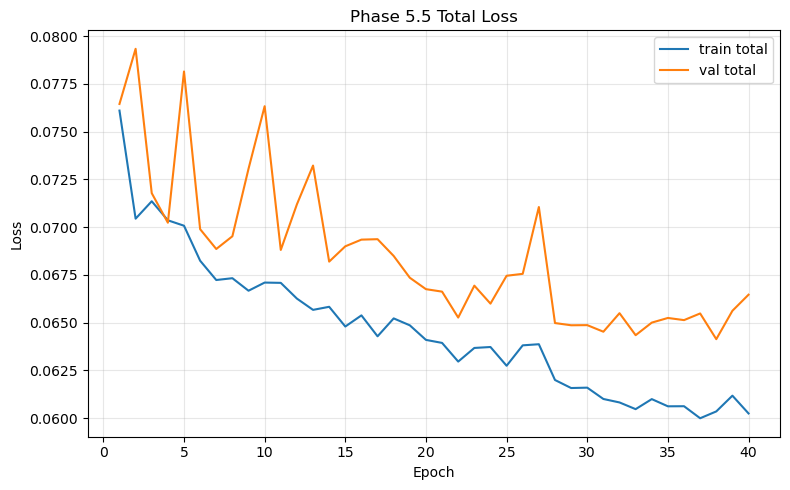

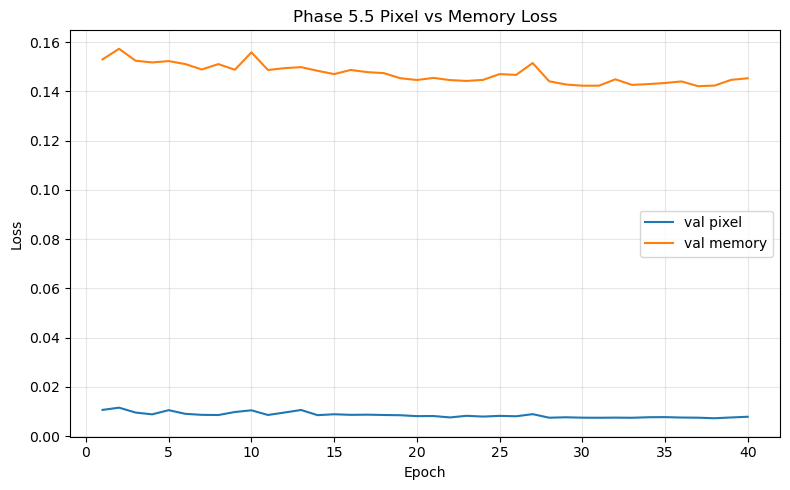

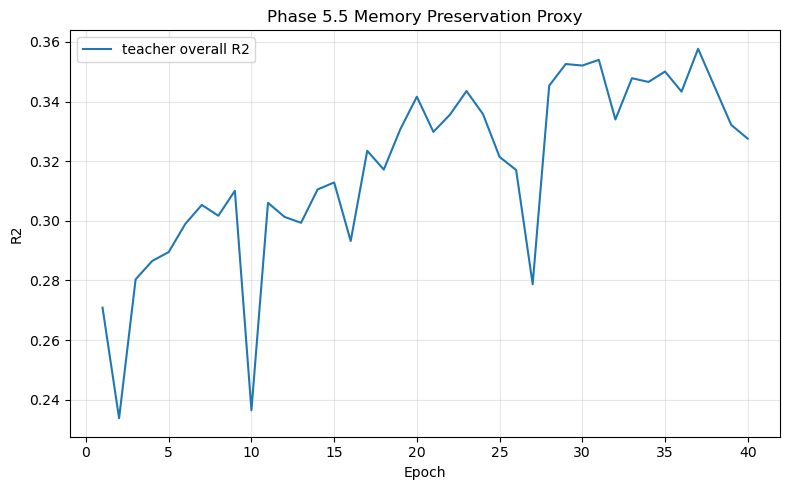

Saved:
  /home/marwa/files/phase1_blackhole_generator/outputs/phase5_5_memory_preserving_reconstruction/phase5_5_loss_curve.png
  /home/marwa/files/phase1_blackhole_generator/outputs/phase5_5_memory_preserving_reconstruction/phase5_5_component_losses.png
  /home/marwa/files/phase1_blackhole_generator/outputs/phase5_5_memory_preserving_reconstruction/phase5_5_teacher_r2_curve.png


In [13]:
history_df = pd.DataFrame(history_rows)

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"].to_numpy(), history_df["train_loss"].to_numpy(), label="train total")
plt.plot(history_df["epoch"].to_numpy(), history_df["val_loss"].to_numpy(), label="val total")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Phase 5.5 Total Loss")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
loss_plot_path = PHASE55_DIR / "phase5_5_loss_curve.png"
plt.savefig(loss_plot_path, dpi=150)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"].to_numpy(), history_df["val_pixel_loss"].to_numpy(), label="val pixel")
plt.plot(history_df["epoch"].to_numpy(), history_df["val_memory_loss"].to_numpy(), label="val memory")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Phase 5.5 Pixel vs Memory Loss")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
component_plot_path = PHASE55_DIR / "phase5_5_component_losses.png"
plt.savefig(component_plot_path, dpi=150)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"].to_numpy(), history_df["val_teacher_overall_r2"].to_numpy(), label="teacher overall R2")
plt.xlabel("Epoch")
plt.ylabel("R2")
plt.title("Phase 5.5 Memory Preservation Proxy")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
r2_plot_path = PHASE55_DIR / "phase5_5_teacher_r2_curve.png"
plt.savefig(r2_plot_path, dpi=150)
plt.show()

print("Saved:")
print(" ", loss_plot_path)
print(" ", component_plot_path)
print(" ", r2_plot_path)

## 13. Load best model and test

In [14]:
best_ckpt = torch.load(NEW_MEMORY_PRESERVING_UNET_PATH, map_location=DEVICE)
model.load_state_dict(best_ckpt["model_state_dict"])
model.to(DEVICE)
model.eval()

new_test_metrics = evaluate_reconstruction(test_loader, model)

print("New memory-preserving reconstructor test metrics:")
for key in ["mae", "mse", "psnr", "ssim", "memory_loss", "teacher_overall_r2", "teacher_overall_corr"]:
    print(f"  {key}: {new_test_metrics[key]:.5f}")

metrics_path = PHASE55_DIR / "phase5_5_test_metrics.json"
with open(metrics_path, "w") as f:
    json.dump(new_test_metrics, f, indent=2)

print("Saved:", metrics_path)

New memory-preserving reconstructor test metrics:
  mae: 0.00847
  mse: 0.00037
  psnr: 34.60606
  ssim: 0.95647
  memory_loss: 0.14567
  teacher_overall_r2: 0.32590
  teacher_overall_corr: 0.57719
Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase5_5_memory_preserving_reconstruction/phase5_5_test_metrics.json


## 14. Old vs new reconstruction comparison

This is the decision cell. The new reconstructor should ideally keep SSIM high while improving teacher memory metrics.

,model,mae,mse,psnr,ssim,memory_loss,teacher_overall_corr,teacher_overall_r2
0,old_phase2_reconstructor,0.009616,0.000402,34.157293,0.946949,0.158352,0.500261,0.246372
1,phase5_5_memory_preserving_reconstructor,0.008473,0.000370,34.606059,0.956466,0.145674,0.577187,0.325900


Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase5_5_memory_preserving_reconstruction/phase5_5_old_vs_new_reconstructor.csv


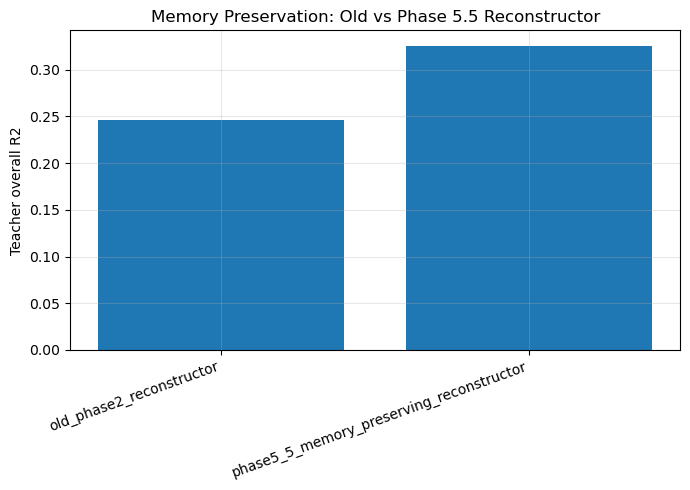

Saved plot: /home/marwa/files/phase1_blackhole_generator/outputs/phase5_5_memory_preserving_reconstruction/phase5_5_old_vs_new_teacher_r2.png


In [15]:
comparison_rows = [
    {
        "model": "old_phase2_reconstructor",
        "mae": old_test_metrics["mae"],
        "mse": old_test_metrics["mse"],
        "psnr": old_test_metrics["psnr"],
        "ssim": old_test_metrics["ssim"],
        "memory_loss": old_test_metrics["memory_loss"],
        "teacher_overall_corr": old_test_metrics["teacher_overall_corr"],
        "teacher_overall_r2": old_test_metrics["teacher_overall_r2"],
    },
    {
        "model": "phase5_5_memory_preserving_reconstructor",
        "mae": new_test_metrics["mae"],
        "mse": new_test_metrics["mse"],
        "psnr": new_test_metrics["psnr"],
        "ssim": new_test_metrics["ssim"],
        "memory_loss": new_test_metrics["memory_loss"],
        "teacher_overall_corr": new_test_metrics["teacher_overall_corr"],
        "teacher_overall_r2": new_test_metrics["teacher_overall_r2"],
    },
]

comparison_df = pd.DataFrame(comparison_rows)
comparison_path = PHASE55_DIR / "phase5_5_old_vs_new_reconstructor.csv"
comparison_df.to_csv(comparison_path, index=False)

display(comparison_df)
print("Saved:", comparison_path)

plt.figure(figsize=(7, 5))
plt.bar(comparison_df["model"], comparison_df["teacher_overall_r2"])
plt.xticks(rotation=20, ha="right")
plt.ylabel("Teacher overall R2")
plt.title("Memory Preservation: Old vs Phase 5.5 Reconstructor")
plt.grid(alpha=0.3)
plt.tight_layout()
comparison_plot_path = PHASE55_DIR / "phase5_5_old_vs_new_teacher_r2.png"
plt.savefig(comparison_plot_path, dpi=150)
plt.show()

print("Saved plot:", comparison_plot_path)

## 15. Per-target memory preservation proxy

This does not replace Phase 4. It is only a fast proxy showing which target signals survive reconstruction better after Phase 5.5.

,target,old_corr,old_r2,new_corr,new_r2,delta_r2
5,spin_evolution,0.717489,0.480544,0.838661,0.679024,0.198481
4,jet_power,0.614146,0.349513,0.700329,0.481486,0.131972
2,turbulence_level,0.112458,0.008943,0.203760,0.037648,0.028705
1,disk_luminosity,0.235517,0.054149,0.276881,0.073590,0.019442
3,instability_index,0.123834,0.012643,0.157460,0.024611,0.011969
0,accretion_rate,0.176471,0.031073,0.197666,0.036648,0.005575


Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase5_5_memory_preserving_reconstruction/phase5_5_per_target_memory_proxy.csv


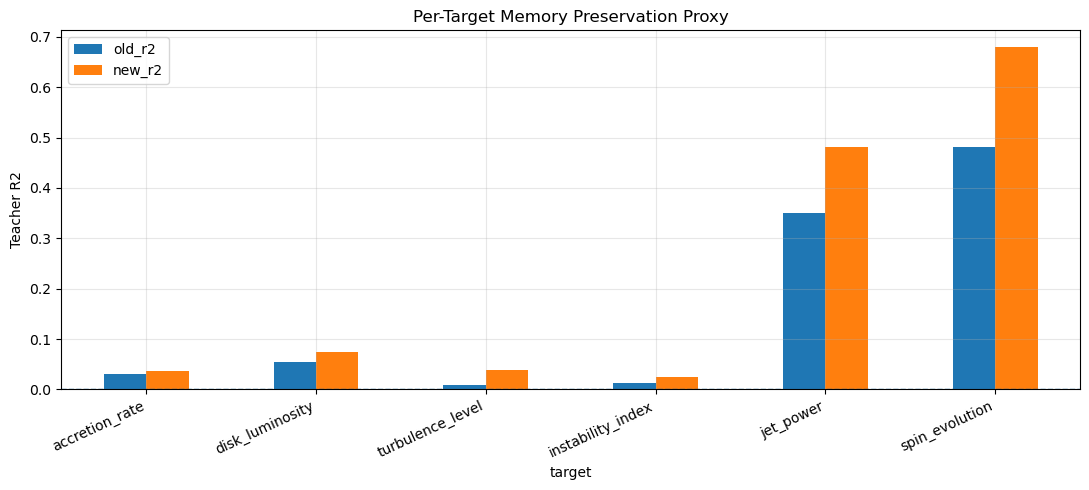

Saved plot: /home/marwa/files/phase1_blackhole_generator/outputs/phase5_5_memory_preserving_reconstruction/phase5_5_per_target_memory_proxy.png


In [16]:
per_target_rows = []
for col in TARGET_COLUMNS:
    per_target_rows.append({
        "target": col,
        "old_corr": old_test_metrics[f"teacher_{col}_corr"],
        "old_r2": old_test_metrics[f"teacher_{col}_r2"],
        "new_corr": new_test_metrics[f"teacher_{col}_corr"],
        "new_r2": new_test_metrics[f"teacher_{col}_r2"],
        "delta_r2": new_test_metrics[f"teacher_{col}_r2"] - old_test_metrics[f"teacher_{col}_r2"],
    })

per_target_proxy_df = pd.DataFrame(per_target_rows).sort_values("delta_r2", ascending=False)
per_target_proxy_path = PHASE55_DIR / "phase5_5_per_target_memory_proxy.csv"
per_target_proxy_df.to_csv(per_target_proxy_path, index=False)

display(per_target_proxy_df)
print("Saved:", per_target_proxy_path)

plot_df = per_target_proxy_df.set_index("target")[['old_r2', 'new_r2']].reindex(TARGET_COLUMNS)
ax = plot_df.plot(kind="bar", figsize=(11, 5))
ax.axhline(0.0, linestyle="--", linewidth=1)
ax.set_ylabel("Teacher R2")
ax.set_title("Per-Target Memory Preservation Proxy")
ax.grid(alpha=0.3)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
per_target_plot_path = PHASE55_DIR / "phase5_5_per_target_memory_proxy.png"
plt.savefig(per_target_plot_path, dpi=150)
plt.show()

print("Saved plot:", per_target_plot_path)

## 16. Prediction contact sheet

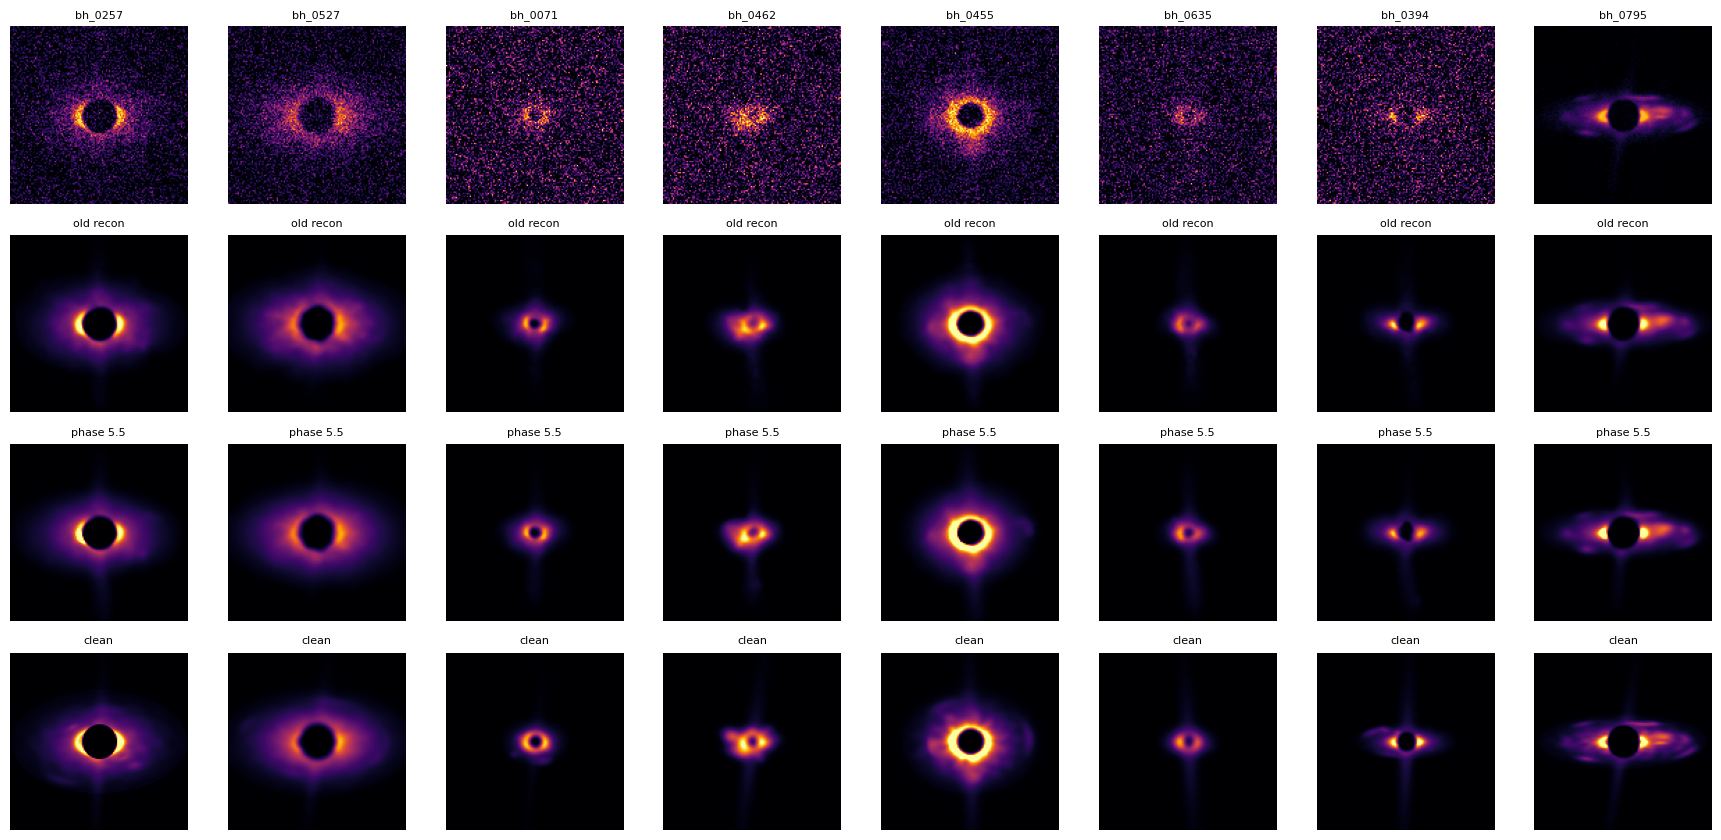

Saved: /home/marwa/files/phase1_blackhole_generator/outputs/phase5_5_memory_preserving_reconstruction/phase5_5_reconstruction_contact_sheet.png


In [17]:
@torch.no_grad()
def make_contact_sheet(old_model, new_model, loader, output_path, n=8):
    old_model.eval()
    new_model.eval()

    noisy, clean, history, sample_ids = next(iter(loader))
    noisy = noisy[:n].to(DEVICE)
    clean = clean[:n].to(DEVICE)
    sample_ids = sample_ids[:n]

    old_pred = old_model(noisy)
    new_pred = new_model(noisy)

    noisy_np = noisy.cpu().numpy()
    clean_np = clean.cpu().numpy()
    old_np = old_pred.cpu().numpy()
    new_np = new_pred.cpu().numpy()

    rows = 4
    fig, axes = plt.subplots(rows, n, figsize=(2.2 * n, 8.5))
    if n == 1:
        axes = axes.reshape(rows, 1)

    for i in range(n):
        axes[0, i].imshow(noisy_np[i, 0], cmap="inferno", vmin=0, vmax=1)
        axes[0, i].set_title(str(sample_ids[i]), fontsize=8)
        axes[0, i].axis("off")

        axes[1, i].imshow(old_np[i, 0], cmap="inferno", vmin=0, vmax=1)
        axes[1, i].set_title("old recon", fontsize=8)
        axes[1, i].axis("off")

        axes[2, i].imshow(new_np[i, 0], cmap="inferno", vmin=0, vmax=1)
        axes[2, i].set_title("phase 5.5", fontsize=8)
        axes[2, i].axis("off")

        axes[3, i].imshow(clean_np[i, 0], cmap="inferno", vmin=0, vmax=1)
        axes[3, i].set_title("clean", fontsize=8)
        axes[3, i].axis("off")

    axes[0, 0].set_ylabel("Noisy", fontsize=10)
    axes[1, 0].set_ylabel("Old", fontsize=10)
    axes[2, 0].set_ylabel("New", fontsize=10)
    axes[3, 0].set_ylabel("Clean", fontsize=10)

    plt.tight_layout()
    plt.savefig(output_path, dpi=150)
    plt.show()
    return output_path

contact_sheet_path = PHASE55_DIR / "phase5_5_reconstruction_contact_sheet.png"
make_contact_sheet(old_reconstructor, model, test_loader, contact_sheet_path, n=8)
print("Saved:", contact_sheet_path)

## 17. Save final summary

In [18]:
summary_text = f"""
Phase 5.5 Summary — Memory-Preserving Reconstruction
=====================================================

Dataset:
  {DATASET_DIR}

Old reconstructor:
  {OLD_PHASE2_CHECKPOINT}

New memory-preserving reconstructor:
  {NEW_MEMORY_PRESERVING_UNET_PATH}

Frozen clean memory teacher:
  {CLEAN_MEMORY_PREDICTOR_CHECKPOINT}

Old reconstruction test metrics:
  MAE              = {old_test_metrics['mae']:.5f}
  PSNR             = {old_test_metrics['psnr']:.5f}
  SSIM             = {old_test_metrics['ssim']:.5f}
  Teacher Corr     = {old_test_metrics['teacher_overall_corr']:.5f}
  Teacher R2       = {old_test_metrics['teacher_overall_r2']:.5f}

New reconstruction test metrics:
  MAE              = {new_test_metrics['mae']:.5f}
  PSNR             = {new_test_metrics['psnr']:.5f}
  SSIM             = {new_test_metrics['ssim']:.5f}
  Teacher Corr     = {new_test_metrics['teacher_overall_corr']:.5f}
  Teacher R2       = {new_test_metrics['teacher_overall_r2']:.5f}

Interpretation:
  Phase 5.5 directly targets the bottleneck discovered after Phase 5:
  reconstructed images looked good but lost memory-relevant morphology.

Decision rule:
  If the new reconstructor improves teacher R2 or teacher correlation without heavily damaging SSIM,
  use this checkpoint in Phase 4 and rerun all input modes.

Next required notebook:
  Phase 4 with UNET_CHECKPOINT = {NEW_MEMORY_PRESERVING_UNET_PATH}
"""

summary_path = PHASE55_DIR / "phase5_5_summary.txt"
with open(summary_path, "w") as f:
    f.write(summary_text)

print(summary_text)
print("Saved:", summary_path)


Phase 5.5 Summary — Memory-Preserving Reconstruction

Dataset:
  /home/marwa/files/phase1_blackhole_generator/data/dataset_phase5_coupled

Old reconstructor:
  /home/marwa/files/phase1_blackhole_generator/outputs/best_unet_physics_aware_phase5.pt

New memory-preserving reconstructor:
  /home/marwa/files/phase1_blackhole_generator/outputs/best_unet_memory_preserving_phase5.pt

Frozen clean memory teacher:
  /home/marwa/files/phase1_blackhole_generator/outputs/phase4_multi_channel_memory_prediction_phase5/best_multi_history_predictor_clean.pt

Old reconstruction test metrics:
  MAE              = 0.00962
  PSNR             = 34.15729
  SSIM             = 0.94695
  Teacher Corr     = 0.50026
  Teacher R2       = 0.24637

New reconstruction test metrics:
  MAE              = 0.00847
  PSNR             = 34.60606
  SSIM             = 0.95647
  Teacher Corr     = 0.57719
  Teacher R2       = 0.32590

Interpretation:
  Phase 5.5 directly targets the bottleneck discovered after Phase 5:
  rec

# 18. What to run after Phase 5.5

Do not overwrite your old Phase 4 results. Create a new Phase 4 output folder and rerun all three modes: `clean`, `noisy`, and `reconstructed`.

Then rerun Phase 4.5 pointed at the new Phase 4 folder.